<a href="https://colab.research.google.com/github/huyle2411-hub/credit-risk-scorecard/blob/main/notebooks/01_data_quality_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Scorecard — Notebook 01: Data-Quality Audit
**Dataset:** Give Me Some Credit (`cs-training.csv`, 150,000 dòng).  
**Mục tiêu notebook này:** Kiểm tra chất lượng dữ liệu trước khi mô hình hóa: soi missing, mã bất thường, outlier, và ghi lại hướng xử lý cho từng vấn đề gặp phải.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

## 1. Nạp dữ liệu
Chạy cell dưới, một nút chọn file sẽ hiện ra → chọn `cs-training.csv` từ máy.  
(File sẽ nằm ở thư mục `/content/` của phiên Colab.)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving cs-training.csv to cs-training.csv


In [ ]:
df = pd.read_csv('cs-training.csv', index_col=0)
print('Đã nạp:', df.shape)

Đã nạp: (150000, 11)


## 2. Cấu trúc dữ liệu
Xem nhanh: kích thước, vài dòng đầu, kiểu dữ liệu từng cột.

In [ ]:
print('Số dòng, số cột:', df.shape)
display(df.head())
df.info()

Số dòng, số cột: (150000, 11)


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

## 3. Cân bằng nhãn (target)
`SeriousDlqin2yrs` = 1 nếu khách từng trễ hạn 90+ ngày trong 2 năm.

Tỷ lệ default (=1): 0.0668  ->  10,026 / 150,000


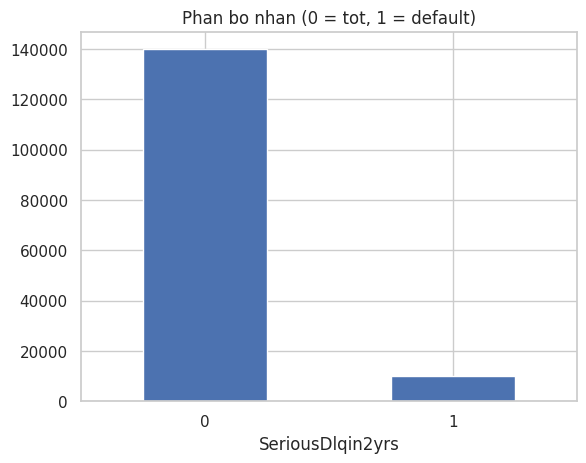

In [ ]:
target = 'SeriousDlqin2yrs'
rate = df[target].mean()
print(f'Tỷ lệ default (=1): {rate:.4f}  ->  {df[target].sum():,} / {len(df):,}')

df[target].value_counts().sort_index().plot(kind='bar')
plt.title('Phan bo nhan (0 = tot, 1 = default)')
plt.xticks(rotation=0); plt.show()

Chỉ ~6.7% là default → dữ liệu **mất cân bằng**. Hệ quả: KHÔNG dùng accuracy để đánh giá (đoán bừa "tất cả tốt" đã đúng 93%). Dùng **AUC / KS / Gini**.

## 4. Giá trị thiếu (missing)

In [ ]:
missing = df.isna().mean().mul(100).round(2)
print(missing[missing > 0].sort_values(ascending=False).to_string())

both = (df['MonthlyIncome'].isna() & df['NumberOfDependents'].isna()).sum()
print(f'\nThieu DONG THOI ca income lan dependents: {both:,} dong')

MonthlyIncome         19.82
NumberOfDependents     2.62

Thieu DONG THOI ca income lan dependents: 3,924 dong


`MonthlyIncome` thiếu ~19.8%, `NumberOfDependents` thiếu ~2.6%, và 3,924 dòng thiếu cả hai (gợi ý cùng một nguyên nhân thu thập). **Làm ở notebook sau:** không xóa dòng — sẽ impute + tạo cờ `income_missing` để giữ tín hiệu "vì sao thiếu".

## 5. Mã bất thường 96 / 98
Ba cột đếm số lần trễ hạn có giá trị 96 và 98 — bất khả thi cho "số lần trễ". Ta kiểm tra: có phải cùng một nhóm khách, và nhóm đó có gì đặc biệt.

In [ ]:
late_cols = ['NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate',
             'NumberOfTime60-89DaysPastDueNotWorse']

for c in late_cols:
    codes = df.loc[df[c] >= 90, c].value_counts().to_dict()
    print(f'{c}: gia tri >=90 -> {codes}')

flagged = (df[late_cols] >= 90).any(axis=1)
print(f'\nSo dong dinh ma bat thuong: {flagged.sum():,}')
print(f'Ty le default TRONG nhom bat thuong: {df.loc[flagged, target].mean():.3f}')
print(f'Ty le default toan bo             : {df[target].mean():.3f}')

NumberOfTime30-59DaysPastDueNotWorse: gia tri >=90 -> {98: 264, 96: 5}
NumberOfTimes90DaysLate: gia tri >=90 -> {98: 264, 96: 5}
NumberOfTime60-89DaysPastDueNotWorse: gia tri >=90 -> {98: 264, 96: 5}

So dong dinh ma bat thuong: 269
Ty le default TRONG nhom bat thuong: 0.546
Ty le default toan bo             : 0.067


Đúng **269 dòng** dính mã này ở cả 3 cột, và tỷ lệ default của nhóm = **54.6%** so với 6.68% chung. → Mã 96/98 **mang tín hiệu rủi ro cực mạnh**, không phải rác. **→** thay 96/98 bằng NaN để xử lý riêng, NHƯNG tạo cờ `late_code_flag` để model học được tín hiệu này. (Đây là điều dễ bị xoá nếu drop/impute mù.)

## 6. Outlier ở biến liên tục

In [ ]:
display(df[['RevolvingUtilizationOfUnsecuredLines','DebtRatio','age','MonthlyIncome']].describe())

print('age = 0                 :', (df['age'] == 0).sum(), 'dong')
print('RevolvingUtilization > 1:', (df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum(), 'dong (max %.0f)' % df['RevolvingUtilizationOfUnsecuredLines'].max())
print('DebtRatio > 1           :', (df['DebtRatio'] > 1).sum(), 'dong (max %.0f)' % df['DebtRatio'].max())

,RevolvingUtilizationOfUnsecuredLines,DebtRatio,age,MonthlyIncome
count,150000.000000,150000.000000,150000.000000,1.202690e+05
mean,6.048438,353.005076,52.295207,6.670221e+03
std,249.755371,2037.818523,14.771866,1.438467e+04
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.029867,0.175074,41.000000,3.400000e+03
50%,0.154181,0.366508,52.000000,5.400000e+03
75%,0.559046,0.868254,63.000000,8.249000e+03
max,50708.000000,329664.000000,109.000000,3.008750e+06


age = 0                 : 1 dong
RevolvingUtilization > 1: 3321 dong (max 50708)
DebtRatio > 1           : 35137 dong (max 329664)


`RevolvingUtilization` và `DebtRatio` lẽ ra là tỷ lệ 0–1 nhưng có giá trị tới hàng chục nghìn; `age` có 1 dòng = 0 (vô lý). **→** cap (winsorize) ở phân vị cao (vd 99%), sửa `age=0`. WOE binning ở notebook sau cũng làm nhẹ tác động outlier một cách tự nhiên.

## 7. Audit memo — tổng kết & quyết định xử lý
| Vấn đề | Con số | Quyết định |
|---|---|---|
| Mất cân bằng | 6.68% default | Đánh giá bằng AUC/KS/Gini |
| MonthlyIncome thiếu | 19.82% | Impute + cờ `income_missing` |
| NumberOfDependents thiếu | 2.62% | Impute = 0 |
| Mã 96/98 (3 cột) | 269 dòng, default 54.6% | → NaN + **cờ `late_code_flag`** (giữ tín hiệu) |
| RevolvingUtil > 1 | 3,321 dòng | Cap ở phân vị 99% |
| DebtRatio > 1 | 35,137 dòng | Cap ở phân vị 99% |
| age = 0 | 1 dòng | Sửa về median/NaN |

→ Sang **Notebook 02** thực hiện các quyết định này, rồi WOE/IV + scorecard.